In [13]:
base_df

,dataset_type,dataset_name,normalization,rmse_mean,mae_mean,label,range_key,data_type
0,all_neg,gaussiandiffdistr_cl0.005_dim=1d_solver=expona...,norm,0.141809,0.115806,all_neg_norm_gaussiandiffdistr_cl0.005_dim=1d_...,all_neg,general
1,all_neg,gaussiandiffdistr_cl0.005_dim=1d_solver=expona...,unnorm,0.123792,0.104201,all_neg_unnorm_gaussiandiffdistr_cl0.005_dim=1...,all_neg,general
2,all_neg,gaussiandiffdistr_cl0.01_dim=1d_solver=exponax...,norm,0.187698,0.155433,all_neg_norm_gaussiandiffdistr_cl0.01_dim=1d_s...,all_neg,general
3,all_neg,gaussiandiffdistr_cl0.01_dim=1d_solver=exponax...,unnorm,0.163835,0.134411,all_neg_unnorm_gaussiandiffdistr_cl0.01_dim=1d...,all_neg,general
4,all_neg,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,norm,0.302313,0.249358,all_neg_norm_gaussiandiffdistr_cl0.03_dim=1d_s...,all_neg,general
...,...,...,...,...,...,...,...,...
371,range_0_3,zigzag_peaks10_amp1.0_dim=1d_solver=exponax_bc...,unnorm,0.764435,0.643592,range_0_3_unnorm_zigzag_peaks10_amp1.0_dim=1d_...,range_0_3,general
372,range_0_3,zigzag_peaks30_amp1.0_dim=1d_solver=exponax_bc...,norm,0.729118,0.622083,range_0_3_norm_zigzag_peaks30_amp1.0_dim=1d_so...,range_0_3,general
373,range_0_3,zigzag_peaks30_amp1.0_dim=1d_solver=exponax_bc...,unnorm,0.675424,0.578925,range_0_3_unnorm_zigzag_peaks30_amp1.0_dim=1d_...,range_0_3,general
374,range_0_3,zigzag_peaks50_amp1.0_dim=1d_solver=exponax_bc...,norm,0.707149,0.574416,range_0_3_norm_zigzag_peaks50_amp1.0_dim=1d_so...,range_0_3,general


In [20]:
base_df[base_df["rmse_mean"].isna()]

,dataset_type,dataset_name,normalization,rmse_mean,mae_mean,label,range_key,data_type
348,range_0_3,gaussiandiffdistr_cl0.2_dim=1d_solver=exponax_...,norm,NaN,NaN,range_0_3_norm_gaussiandiffdistr_cl0.2_dim=1d_...,range_0_3,general
349,range_0_3,gaussiandiffdistr_cl0.2_dim=1d_solver=exponax_...,unnorm,NaN,NaN,range_0_3_unnorm_gaussiandiffdistr_cl0.2_dim=1...,range_0_3,general


In [15]:
base_df["dataset_type"].unique()

array(['all_neg', 'all_pos', 'pos_neg', 'range_-2_0', 'range_-2_2',
       'range_-3_0', 'range_-3_3', 'range_0_0.5', 'range_0_2',
       'range_0_3'], dtype=object)

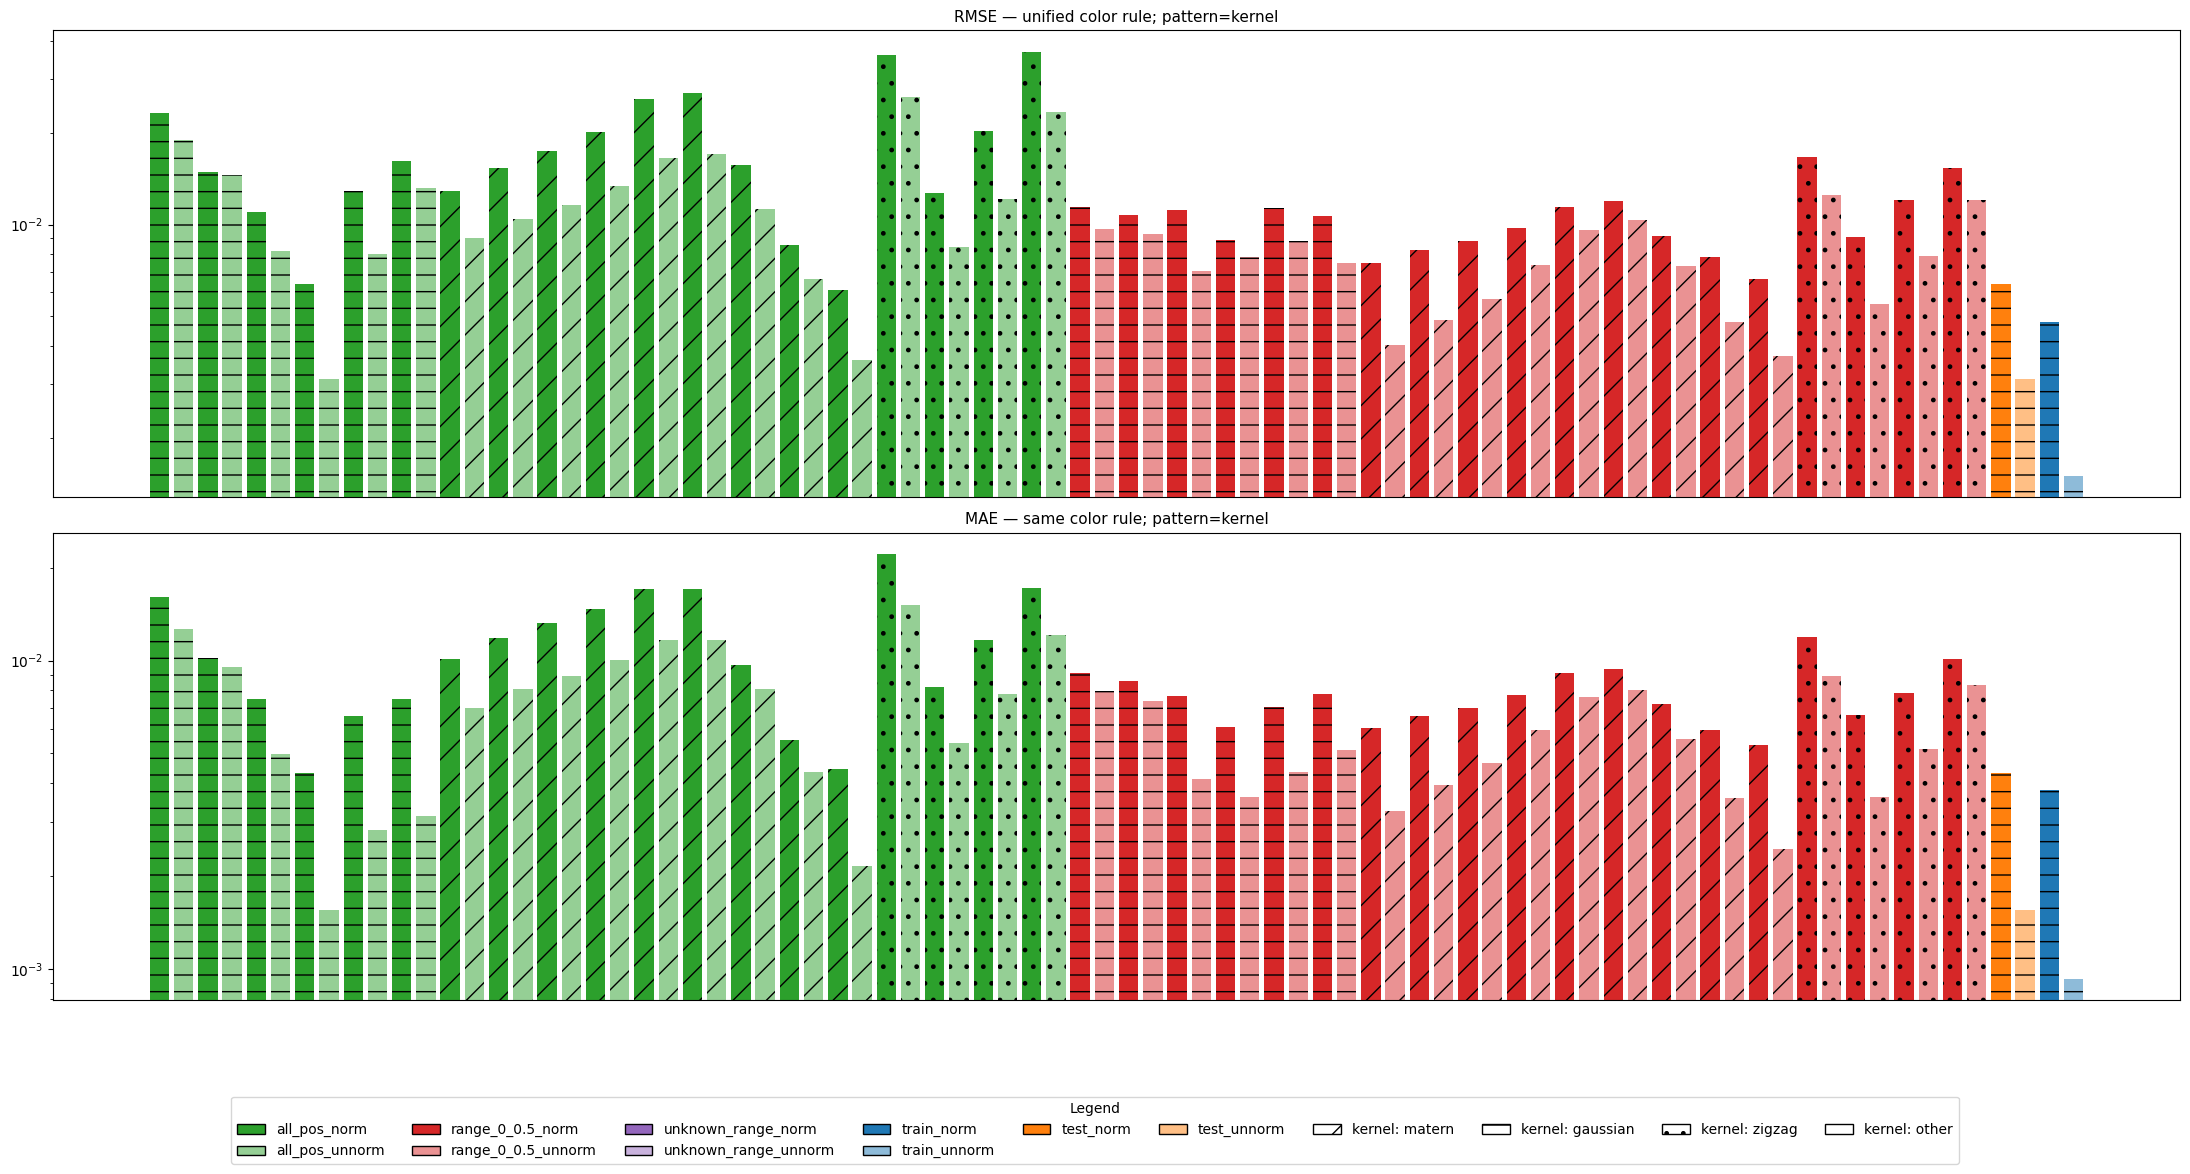

In [30]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re
from matplotlib.patches import Patch

# ===== 路径（按需改）=====
CSV_BASE    = "generalization_plots/metrics_summary.csv"  # 两张图的基底（相同）
CSV_OVERLAY = "test_train_plots/metrics_summary.csv"      # 叠加条目（test/train）

# ===== 聚合 =====
def agg_summary(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df['sample_index'].isin([0,1,2,3,4])]
    rows = []
    for (dtype, dname), g in df.groupby(['dataset_type','dataset_name']):
        rows += [
            {'dataset_type':dtype,'dataset_name':dname,'normalization':'norm',
             'rmse_mean':g['rmse_norm'].mean(),'mae_mean':g['mae_norm'].mean()},
            {'dataset_type':dtype,'dataset_name':dname,'normalization':'unnorm',
             'rmse_mean':g['rmse_unnorm'].mean(),'mae_mean':g['mae_unnorm'].mean()},
        ]
    out = pd.DataFrame(rows)
    out['label'] = out['dataset_type'] + "_" + out['normalization'] + "_" + out['dataset_name']
    return out

# ===== 辅助：kernel / 简短标签 / range 解析 / data_type 解析 =====
def kernel_from_name(name: str) -> str:
    s = str(name).lower()
    if 'matern' in s:   return 'matern'
    if 'gaussian' in s: return 'gaussian'
    if 'zigzag' in s:   return 'zigzag'
    return 'other'

def short_label(dataset_name: str, kernel: str) -> str:
    s = str(dataset_name).lower()
    if kernel=='matern':
        cl = re.search(r'cl([0-9\.]+)', s); nu = re.search(r'nu([0-9\.]+)', s)
        return f"cl{cl.group(1) if cl else '?'}_nu{nu.group(1) if nu else '?'}"
    if kernel=='gaussian':
        cl = re.search(r'cl([0-9\.]+)', s);  return f"cl{cl.group(1) if cl else '?'}"
    if kernel=='zigzag':
        pk = re.search(r'peaks([0-9]+)', s); return f"peaks{pk.group(1) if pk else '?'}"
    return 'other'

def parse_range_from_text(text: str) -> str | None:
    t = str(text).lower()
    if 'all_pos' in t: return 'all_pos'
    m = re.search(r'range[_\-\s]?0[_\-\s]?[_\-\s]?(\d+(?:\.\d+)?)', t)
    if m:
        val = m.group(1).replace('.', '_')
        return f"range_0_{val}"
    return None

def parse_data_type(s1: str, s2: str) -> str:
    text = f"{s1} {s2}".lower()
    if 'train' in text: return 'train'
    if 'test'  in text: return 'test'
    return 'general'

# ===== 读取并聚合 =====
base_df    = agg_summary(CSV_BASE)       # 基底（两图一致）
# base_df = base_df[base_df["dataset_type"].isin(["all_pos","range_0_0.5","range_0_2","range_0_3"])]
base_df = base_df[base_df["dataset_type"].isin(["all_pos","range_0_0.5"])]
overlay_df = agg_summary(CSV_OVERLAY)    # 叠加（会拼到末尾）

# ===== 统一出 range_key & data_type =====
name2range = base_df.drop_duplicates('dataset_name').set_index('dataset_name')['dataset_type'].to_dict()

def attach_range_and_dtype(df: pd.DataFrame, is_overlay: bool) -> pd.DataFrame:
    df = df.copy()
    # range_key
    if not is_overlay:
        rk = df['dataset_type'].copy()
        miss = rk.isna() | (rk == '')
        if miss.any():
            rk.loc[miss] = df.loc[miss, 'dataset_name'].apply(parse_range_from_text)
        df['range_key'] = rk.fillna('unknown_range')
        df['data_type'] = 'general'
    else:
        from_name = df['dataset_name'].map(name2range)
        from_text = df['dataset_name'].apply(parse_range_from_text)
        df['range_key'] = from_name.where(from_name.notna(), from_text).fillna('unknown_range')
        df['data_type'] = [parse_data_type(dt, dn) for dt, dn in zip(df['dataset_type'], df['dataset_name'])]
    return df

base_df    = attach_range_and_dtype(base_df,    is_overlay=False)
overlay_df = attach_range_and_dtype(overlay_df, is_overlay=True)

# ===== 两张图的数据：都用 base + overlay 的拼接（顺序：先基底，后叠加）=====
top_df = pd.concat([base_df, overlay_df], ignore_index=True)
bot_df = pd.concat([base_df, overlay_df], ignore_index=True)

# ===== 颜色映射（上下统一）：general 用 range；overlay 用 train/test；深浅=norm/unnorm =====
# range 调色板（按 base 的顺序）
base_ranges = list(dict.fromkeys(base_df['range_key'].tolist()))
for rk in overlay_df['range_key'].unique():
    if rk not in base_ranges:
        base_ranges.append(rk)

# palette   = plt.cm.tab10.colors
# range_rgb = {rk: palette[i % len(palette)] for i, rk in enumerate(base_ranges)}

palette = plt.cm.tab10.colors
offset = 2  # 跳过 tab10 的前两种颜色（蓝、橙）
range_rgb = {rk: palette[(i + offset) % len(palette)] for i, rk in enumerate(base_ranges)}

# train/test 固定色
dt_palette = {'train': (0.12, 0.47, 0.71), 'test': (1.00, 0.50, 0.05)}

def color_rgba(row):
    # overlay 使用 train/test；base 使用 range
    if row.get('data_type') in ('train', 'test'):
        rgb = dt_palette[row['data_type']]
    else:
        rgb = range_rgb.get(row['range_key'], (0.6, 0.6, 0.6))
    alpha = 1.0 if row['normalization']=='norm' else 0.5
    return (*rgb[:3], alpha)

# 顶/底图统一配色
top_df['color'] = top_df.apply(color_rgba, axis=1)
bot_df['color'] = bot_df.apply(color_rgba, axis=1)

# ===== kernel → hatch（两张图都加 pattern）=====
hatch_map = {'matern':'/','gaussian':'-','zigzag':'.','other':None}
top_df['kernel'] = top_df['dataset_name'].apply(kernel_from_name)
bot_df['kernel'] = bot_df['dataset_name'].apply(kernel_from_name)
top_df['hatch']  = top_df['kernel'].map(hatch_map)
bot_df['hatch']  = bot_df['kernel'].map(hatch_map)

# x 轴短标签
top_df['label_2'] = top_df.apply(lambda r: short_label(r['dataset_name'], r['kernel']), axis=1)
bot_df['label_2'] = bot_df.apply(lambda r: short_label(r['dataset_name'], r['kernel']), axis=1)

x_top = np.arange(len(top_df))
x_bot = np.arange(len(bot_df))

# ===== 画图 =====
fig = plt.figure(figsize=(22, 12))

# --- 上图：RMSE（去边框；有 hatch）---
ax1 = plt.subplot(2,1,1)
b1 = ax1.bar(x_top, top_df['rmse_mean'], color=top_df['color'].tolist(),
             edgecolor='black', linewidth=0)   # 边框线去掉（linewidth=0），但保留 edgecolor 以显示 hatch
for bar, h in zip(b1, top_df['hatch'].tolist()):
    if h: bar.set_hatch(h)
ax1.set_yscale('log')
ax1.set_title('RMSE — unified color rule; pattern=kernel', fontsize=11)
ax1.set_xticks(x_top)
ax1.set_xticklabels(top_df['label_2'], rotation=90, fontsize=8)
ax1.set_xticks([])
ax1.set_xlabel(None)  # 不加 x label

# --- 下图：MAE（去边框；也加 hatch）---
ax2 = plt.subplot(2,1,2)
b2 = ax2.bar(x_bot, bot_df['mae_mean'], color=bot_df['color'].tolist(),
             edgecolor='black', linewidth=0)   # 边框线去掉，保留 hatch 能见
for bar, h in zip(b2, bot_df['hatch'].tolist()):
    if h: bar.set_hatch(h)
ax2.set_yscale('log')
ax2.set_title('MAE — same color rule; pattern=kernel', fontsize=11)
ax2.set_xticks(x_bot)
ax2.set_xticklabels(bot_df['label_2'], rotation=90, fontsize=8)
ax2.set_xticks([])
ax2.set_xlabel(None)  # 不加 x label

# ===== Legend =====
legend_elements = []

# range（基底配色；示例深浅对应 norm/unnorm）
for rk in base_ranges:
    rgb = range_rgb[rk]
    legend_elements.append(Patch(facecolor=(*rgb[:3],1.0), edgecolor='black', label=f"{rk}_norm"))
    legend_elements.append(Patch(facecolor=(*rgb[:3],0.5), edgecolor='black', label=f"{rk}_unnorm"))

# train/test（叠加配色；示例深浅对应 norm/unnorm）
for dt, rgb in dt_palette.items():
    legend_elements.append(Patch(facecolor=(*rgb[:3],1.0), edgecolor='black', label=f"{dt}_norm"))
    legend_elements.append(Patch(facecolor=(*rgb[:3],0.5), edgecolor='black', label=f"{dt}_unnorm"))

# kernel 的 hatch（两图都有）
for kname, hatch in hatch_map.items():
    legend_elements.append(Patch(facecolor='white', edgecolor='black', hatch=hatch if hatch else '', label=f"kernel: {kname}"))

plt.tight_layout(rect=[0,0.15,1,1])
ncol = min(10, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.02), ncol=ncol,
           title='Legend', frameon=True)

plt.show()


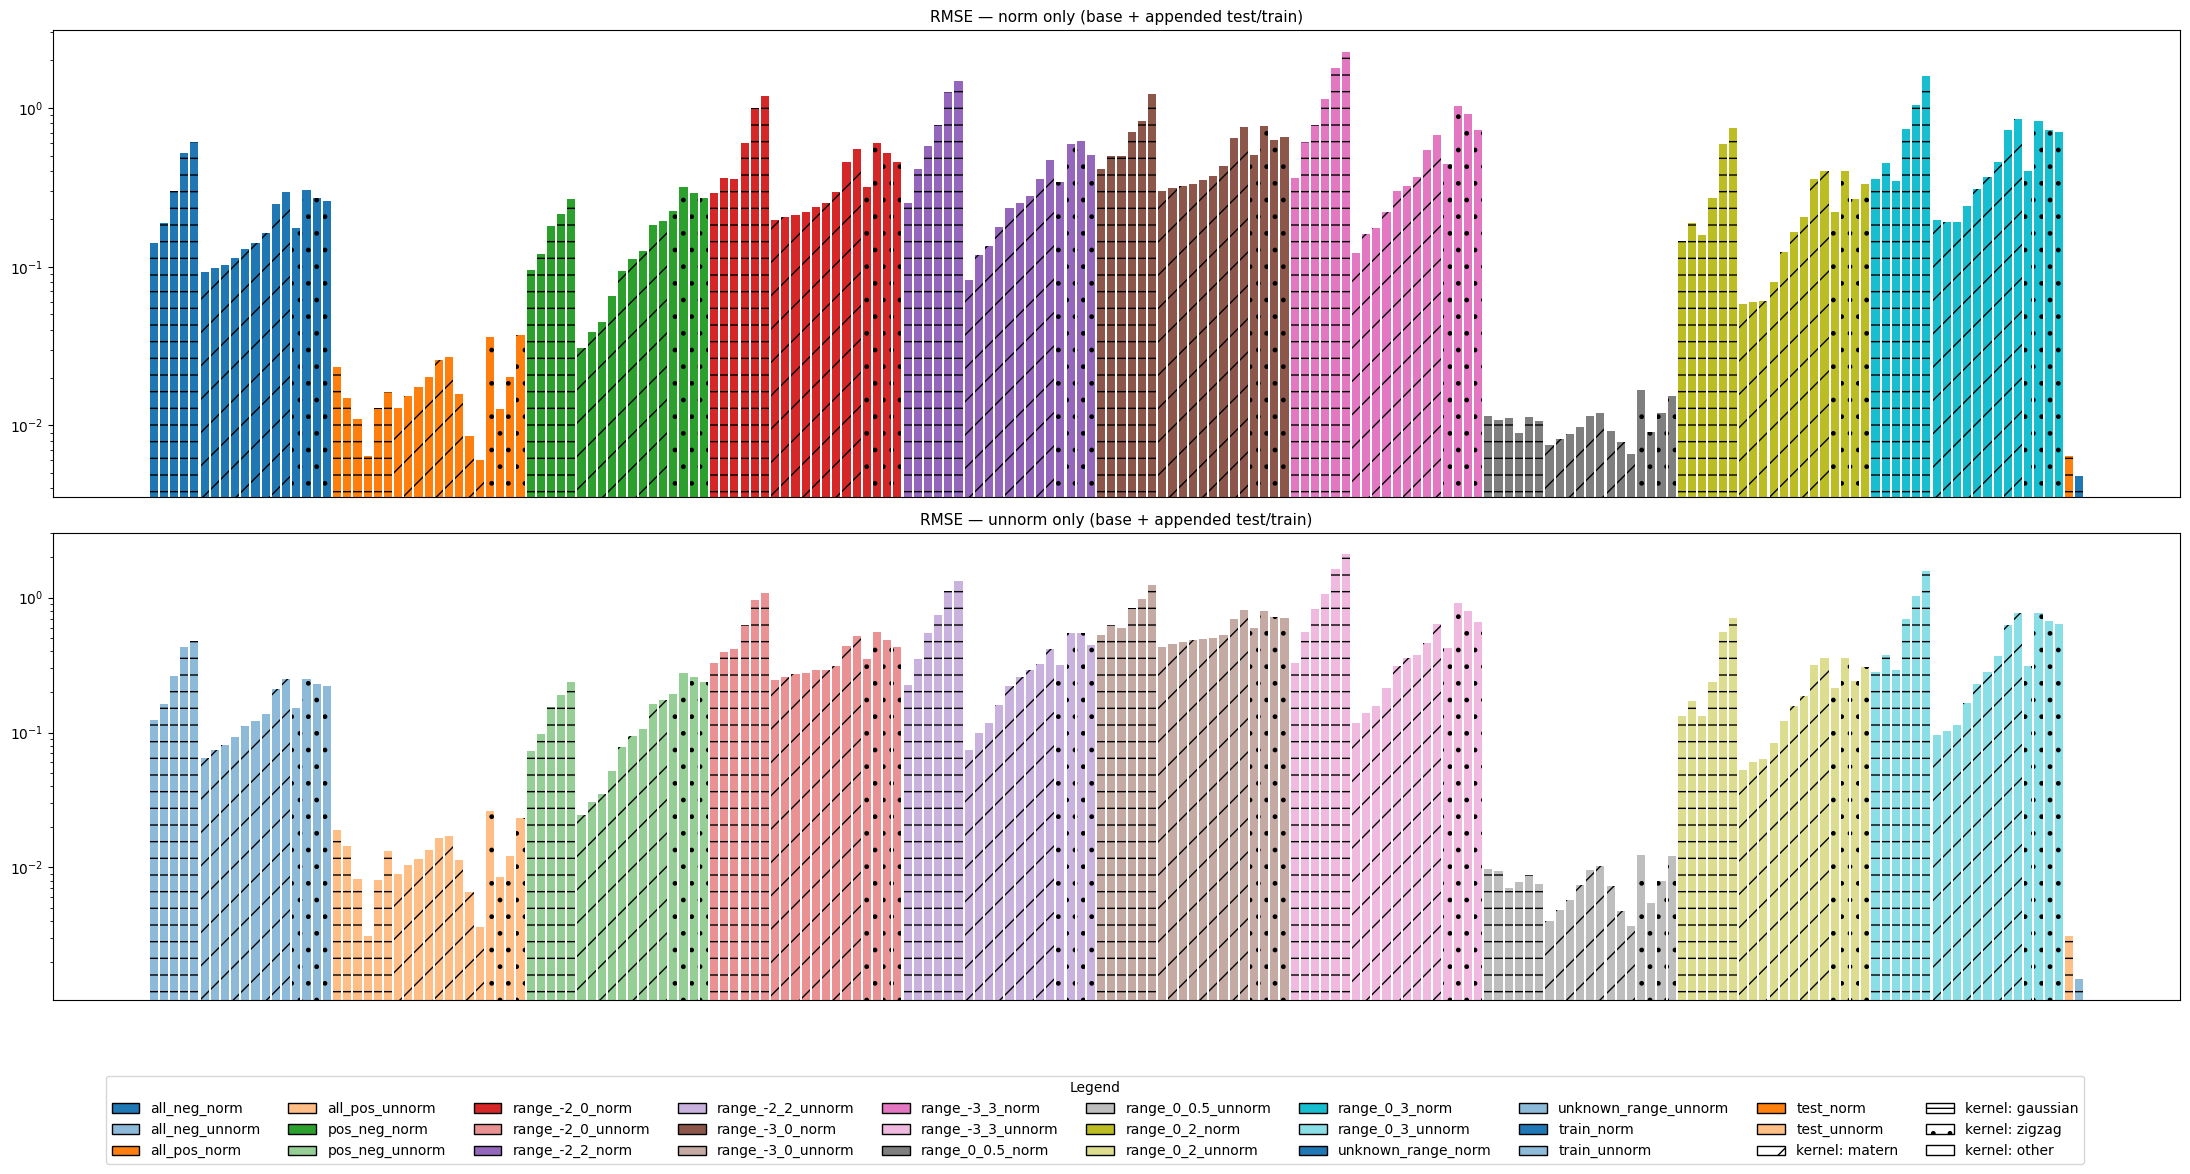

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re
from matplotlib.patches import Patch

# ===== 路径（按需改）=====
CSV_BASE    = "generalization_plots/metrics_summary.csv"  # 两张图的基底（相同）
CSV_OVERLAY = "test_train_plots/metrics_summary.csv"      # 追加的条目（test/train）

# ===== 聚合 =====
def agg_summary(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df['sample_index'].isin([0,1,2,3,4])]
    rows = []
    for (dtype, dname), g in df.groupby(['dataset_type','dataset_name']):
        rows += [
            {'dataset_type':dtype,'dataset_name':dname,'normalization':'norm',
             'rmse_mean':g['rmse_norm'].mean(),'mae_mean':g['mae_norm'].mean()},
            {'dataset_type':dtype,'dataset_name':dname,'normalization':'unnorm',
             'rmse_mean':g['rmse_unnorm'].mean(),'mae_mean':g['mae_unnorm'].mean()},
        ]
    out = pd.DataFrame(rows)
    out['label'] = out['dataset_type'] + "_" + out['normalization'] + "_" + out['dataset_name']
    return out

# ===== 辅助：kernel / 简短标签 / range 解析 / data_type 解析 =====
def kernel_from_name(name: str) -> str:
    s = str(name).lower()
    if 'matern' in s:   return 'matern'
    if 'gaussian' in s: return 'gaussian'
    if 'zigzag' in s:   return 'zigzag'
    return 'other'

def short_label(dataset_name: str, kernel: str) -> str:
    s = str(dataset_name).lower()
    if kernel=='matern':
        cl = re.search(r'cl([0-9\.]+)', s); nu = re.search(r'nu([0-9\.]+)', s)
        return f"cl{cl.group(1) if cl else '?'}_nu{nu.group(1) if nu else '?'}"
    if kernel=='gaussian':
        cl = re.search(r'cl([0-9\.]+)', s);  return f"cl{cl.group(1) if cl else '?'}"
    if kernel=='zigzag':
        pk = re.search(r'peaks([0-9]+)', s); return f"peaks{pk.group(1) if pk else '?'}"
    return 'other'

def parse_range_from_text(text: str) -> str | None:
    t = str(text).lower()
    if 'all_pos' in t: return 'all_pos'
    m = re.search(r'range[_\-\s]?0[_\-\s]?[_\-\s]?(\d+(?:\.\d+)?)', t)
    if m:
        val = m.group(1).replace('.', '_')
        return f"range_0_{val}"
    return None

def parse_data_type(s1: str, s2: str) -> str:
    text = f"{s1} {s2}".lower()
    if 'train' in text: return 'train'
    if 'test'  in text: return 'test'
    return 'general'

# ===== 读取并聚合 =====
base_df    = agg_summary(CSV_BASE)       # 基底（两图一致）
# base_df = base_df[base_df["dataset_type"].isin(["all_pos","range_0_0.5","range_0_2","range_0_3"])]
base_df = base_df[base_df["dataset_type"].isin(["all_pos","range_0_0.5"])]
overlay_df = agg_summary(CSV_OVERLAY)    # 叠加（拼到末尾）

# ===== 统一出 range_key & data_type =====
name2range = base_df.drop_duplicates('dataset_name').set_index('dataset_name')['dataset_type'].to_dict()

def attach_range_and_dtype(df: pd.DataFrame, is_overlay: bool) -> pd.DataFrame:
    df = df.copy()
    if not is_overlay:
        rk = df['dataset_type'].copy()
        miss = rk.isna() | (rk == '')
        if miss.any():
            rk.loc[miss] = df.loc[miss, 'dataset_name'].apply(parse_range_from_text)
        df['range_key'] = rk.fillna('unknown_range')
        df['data_type'] = 'general'
    else:
        from_name = df['dataset_name'].map(name2range)
        from_text = df['dataset_name'].apply(parse_range_from_text)
        df['range_key'] = from_name.where(from_name.notna(), from_text).fillna('unknown_range')
        df['data_type'] = [parse_data_type(dt, dn) for dt, dn in zip(df['dataset_type'], df['dataset_name'])]
    return df

base_df    = attach_range_and_dtype(base_df,    is_overlay=False)
overlay_df = attach_range_and_dtype(overlay_df, is_overlay=True)

# ===== 合并（顺序：先基底，后叠加）=====
all_df = pd.concat([base_df, overlay_df], ignore_index=True)

# ===== 颜色映射（上下统一）：base 用 range；overlay 用 train/test；深浅=norm/unnorm =====
# range 调色板（基于 base 的顺序）
base_ranges = list(dict.fromkeys(base_df['range_key'].tolist()))
for rk in overlay_df['range_key'].unique():
    if rk not in base_ranges:
        base_ranges.append(rk)
palette = plt.cm.tab10.colors
offset = 2  # 跳过 tab10 的前两种颜色（蓝、橙）
range_rgb = {rk: palette[(i + offset) % len(palette)] for i, rk in enumerate(base_ranges)}

# train/test 固定色
dt_palette = {'train': (0.12, 0.47, 0.71), 'test': (1.00, 0.50, 0.05)}

def color_rgba(row):
    # overlay 使用 train/test；base 使用 range
    if row.get('data_type') in ('train', 'test'):
        rgb = dt_palette[row['data_type']]
    else:
        rgb = range_rgb.get(row['range_key'], (0.6, 0.6, 0.6))
    alpha = 1.0 if row['normalization']=='norm' else 0.5
    return (*rgb[:3], alpha)

# kernel → hatch（两图都用）
hatch_map = {'matern':'/','gaussian':'-','zigzag':'.','other':None}
all_df['kernel'] = all_df['dataset_name'].apply(kernel_from_name)
all_df['hatch']  = all_df['kernel'].map(hatch_map)
all_df['color']  = all_df.apply(color_rgba, axis=1)
all_df['label_2'] = all_df.apply(lambda r: short_label(r['dataset_name'], r['kernel']), axis=1)

# ===== 按 normalization 分成两份：上=norm，下=unnorm =====
df_norm  = all_df[all_df['normalization'] == 'norm'  ].reset_index(drop=True)
df_unnrm = all_df[all_df['normalization'] == 'unnorm'].reset_index(drop=True)

# ===== 画图（只画 RMSE；上=norm，下=unnorm）=====
fig = plt.figure(figsize=(22, 12))

# --- 上图：RMSE (norm) ---
ax1 = plt.subplot(2,1,1)
x1 = np.arange(len(df_norm))
bars1 = ax1.bar(x1, df_norm['rmse_mean'], color=df_norm['color'].tolist(),
                edgecolor='black', linewidth=0)  # 去边框线（linewidth=0），保留 hatch 可见性
for bar, h in zip(bars1, df_norm['hatch'].tolist()):
    if h: bar.set_hatch(h)
ax1.set_yscale('log')
ax1.set_title('RMSE — norm only (base + appended test/train)', fontsize=11)
ax1.set_xticks(x1)
ax1.set_xticklabels(df_norm['label_2'], rotation=90, fontsize=8)
ax1.set_xticks([])
ax1.set_xlabel(None)  # 不加 x label

# --- 下图：RMSE (unnorm) ---
ax2 = plt.subplot(2,1,2)
x2 = np.arange(len(df_unnrm))
bars2 = ax2.bar(x2, df_unnrm['rmse_mean'], color=df_unnrm['color'].tolist(),
                edgecolor='black', linewidth=0)  # 去边框线
for bar, h in zip(bars2, df_unnrm['hatch'].tolist()):
    if h: bar.set_hatch(h)
ax2.set_yscale('log')
ax2.set_title('RMSE — unnorm only (base + appended test/train)', fontsize=11)
ax2.set_xticks(x2)
ax2.set_xticklabels(df_unnrm['label_2'], rotation=90, fontsize=8)
ax2.set_xticks([])
ax2.set_xlabel(None)

# ===== Legend（range 的深浅、train/test 的深浅、kernel 的 pattern）=====
legend_elements = []
# range（示例深浅）
for rk in base_ranges:
    rgb = range_rgb[rk]
    legend_elements.append(Patch(facecolor=(*rgb[:3],1.0), edgecolor='black', label=f"{rk}_norm"))
    legend_elements.append(Patch(facecolor=(*rgb[:3],0.5), edgecolor='black', label=f"{rk}_unnorm"))
# train/test（示例深浅）
for dt, rgb in dt_palette.items():
    legend_elements.append(Patch(facecolor=(*rgb[:3],1.0), edgecolor='black', label=f"{dt}_norm"))
    legend_elements.append(Patch(facecolor=(*rgb[:3],0.5), edgecolor='black', label=f"{dt}_unnorm"))
# kernel 的 hatch（两图都有）
for kname, hatch in hatch_map.items():
    legend_elements.append(Patch(facecolor='white', edgecolor='black', hatch=hatch if hatch else '', label=f"kernel: {kname}"))

plt.tight_layout(rect=[0,0.15,1,1])
ncol = min(10, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.02), ncol=ncol,
           title='Legend', frameon=True)
plt.show()
